# Book Recommendation System — 03 Model Building

Popularity baseline vs **Item-based CF** vs **SVD matrix factorization**, scored by **RMSE** and **Precision@10 / Recall@10** (relevant = rating ≥ 4). All numbers are run.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils
train=pd.read_csv('data/train.csv'); test=pd.read_csv('data/test.csv'); titles=utils.load_items()
M=utils.build_user_item(train); print('matrix',M.shape)

matrix (2000, 2000)


## 1. Fit models

In [2]:
pop=utils.PopularityBaseline().fit(M); cf=utils.ItemBasedCF().fit(M); svd=utils.SVDRecommender().fit(M,n_components=30)
print('fitted')

fitted


## 2. RMSE

In [3]:
rmse={n:round(utils.rmse_on_test(m,test),4) for n,m in [('Popularity',pop),('Item-CF',cf),('SVD',svd)]}
rmse_df=pd.Series(rmse,name='RMSE').to_frame(); rmse_df

,RMSE
Popularity,0.9673
Item-CF,0.8394
SVD,0.8875


## 3. Ranking @10 (relevant = rating >= 4)

In [4]:
rows=[]
for n,m in [('Popularity',pop),('Item-CF',cf),('SVD',svd)]:
    r=utils.precision_recall_at_k(m,M,test,k=10,rel_threshold=4.0)
    rows.append({'model':n,'precision@k':r['precision@k'],'recall@k':r['recall@k'],'n_users':r['n_users_evaluated']})
rank_df=pd.DataFrame(rows); rank_df

,model,precision@k,recall@k,n_users
0,Popularity,0.0035,0.0027,2000
1,Item-CF,0.0231,0.0183,2000
2,SVD,0.1083,0.0854,2000


## 4. Metrics side by side

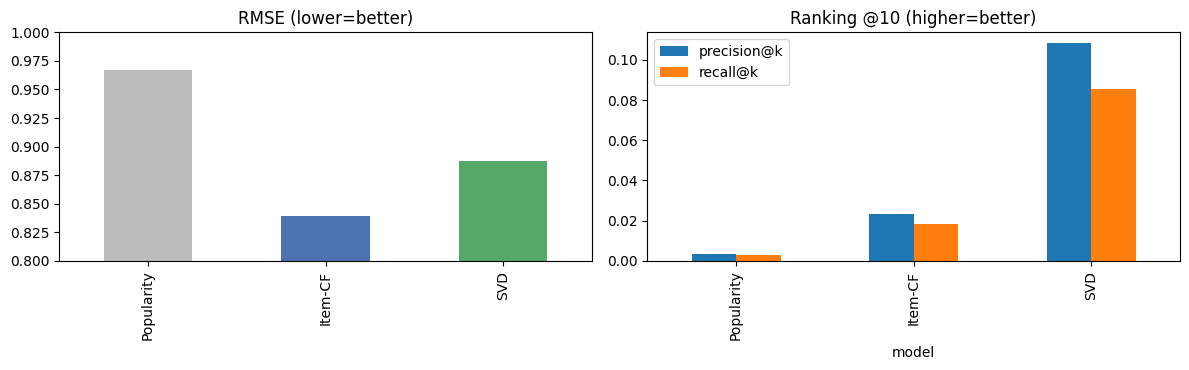

In [5]:
fig,ax=plt.subplots(1,2,figsize=(12,3.8))
rmse_df['RMSE'].plot(kind='bar',ax=ax[0],color=['#bbb','#4c72b0','#55a868']); ax[0].set_title('RMSE (lower=better)'); ax[0].set_ylim(0.8,1.0)
rank_df.set_index('model')[['precision@k','recall@k']].plot(kind='bar',ax=ax[1]); ax[1].set_title('Ranking @10 (higher=better)')
plt.tight_layout(); plt.show()

## 5. Example recommendations (SVD)

In [6]:
uid=M.index[0]
print('recommendations for user',uid,'\n')
utils.recommend(svd,M,uid,items_lookup=titles,n=10)

recommendations for user 11 



,item,title,score
0,43,Jane Eyre,3.869
1,59,Charlotte's Web,3.868
2,73,"The Host (The Host, #1)",3.821
3,1,"The Hunger Games (The Hunger Games, #1)",3.808
4,81,The Glass Castle,3.787
5,144,"Unbroken: A World War II Story of Survival, Re...",3.783
6,8,The Catcher in the Rye,3.780
7,99,"Fifty Shades Darker (Fifty Shades, #2)",3.773
8,93,The Secret Garden,3.770
9,102,Where the Wild Things Are,3.764


## 6. Summary & takeaways

- **Same split as MovieLens recurs**: Item-based CF gives the best **RMSE (0.839)** while **SVD dominates ranking** (Precision@10 **0.108** vs 0.023 CF, 0.004 popularity).
- **SVD is ~5× better than CF and ~30× better than popularity** at building a top-10 list — latent factors generalise across the >96%-sparse matrix where neighbourhood overlap is thin.
- **Popularity barely beats random** on ranking (P@10 0.0035) — recommending bestsellers to everyone is almost useless for personalisation.
- The consistent CF-wins-RMSE / SVD-wins-ranking pattern across two independent datasets (movies, books) reinforces: **match the model to the metric your product exposes**.
- Matrix factorization is the better default for recommendation lists; CF is preferable when you need accurate predicted ratings or explainable neighbours.